# Flowboard SaaS Funnel Analysis
## Notebook 1: Analysis

**Analyst:** Alaz Peker-Röhrig  
**Date:** March 2026  

---

### Business Question

Flowboard is a SaaS project management and collaboration tool. The product team wants to understand:

1. **Where are we losing the most potential customers** in the journey from first website visit to paid subscription?
2. **Which user segments** (by acquisition channel, device, company size) show the strongest or weakest conversion?
3. **What actionable changes** can we recommend to improve conversion rates?

This notebook covers the full technical pipeline: data loading, quality assessment, cleaning, funnel analysis, and segmentation.

---
## 1. Setup

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import sqlite3
import os
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

COLORS = {
    'primary': '#2563EB',
    'secondary': '#64748B',
    'accent': '#F59E0B',
    'success': '#10B981',
    'danger': '#EF4444',
    'light': '#F1F5F9',
}

FUNNEL_COLORS = ['#2563EB', '#3B82F6', '#60A5FA', '#93C5FD', '#BFDBFE']
FUNNEL_ORDER = ['visit_landing_page', 'sign_up', 'complete_onboarding', 'activate_feature', 'subscribe_paid']
FUNNEL_LABELS = ['Visit Landing Page', 'Sign Up', 'Complete Onboarding', 'Activate Feature', 'Subscribe (Paid)']

---
## 2. Data Loading & Initial Inspection

In [89]:
events = pd.read_csv('C:\\Users\\alazp\\Desktop\\SaaS_Funnel_Analysis\\flowboard_events.csv')
users = pd.read_csv('C:\\Users\\alazp\\Desktop\\SaaS_Funnel_Analysis\\flowboard_users.csv')

print(f'Events: {events.shape[0]:,} rows, {events.shape[1]} columns')
print(f'Users:  {users.shape[0]:,} rows, {users.shape[1]} columns')

Events: 208,329 rows, 13 columns
Users:  20,000 rows, 7 columns


In [90]:
events.head(10)

,event_id,user_id,session_id,event_type,event_name,event_timestamp,channel,device,operating_system,country,company_size,plan,event_property
0,E0000001,U18064,S526845,funnel,visit_landing_page,2024-07-01 00:32:28.000000,direct,desktop,macOS,United States,1-10,NaN,NaN
1,E0000002,U18064,S526845,page_view,features_page,2024-07-01 00:37:05.141597,direct,desktop,macOS,United States,1-10,NaN,NaN
2,E0000003,U08573,S725977,funnel,visit_landing_page,2024-07-01 00:37:57.000000,organic_search,mobile,Android,United States,1000+,NaN,NaN
3,E0000004,U08573,S725977,page_view,blog_post,2024-07-01 00:42:42.180924,organic_search,mobile,Android,United States,1000+,NaN,NaN
4,E0000005,U18064,S526845,funnel,sign_up,2024-07-01 00:45:23.184424,direct,desktop,macOS,United States,1-10,NaN,NaN
5,E0000006,U08573,S725977,page_view,blog_post,2024-07-01 00:46:16.667224,organic_search,mobile,Android,United States,1000+,NaN,NaN
6,E0000007,U03042,S174258,funnel,visit_landing_page,2024-07-01 00:47:15.000000,organic_search,mobile,iOS,United States,1-10,NaN,NaN
7,E0000008,U08573,S725977,page_view,pricing_page,2024-07-01 00:47:51.006985,organic_search,mobile,Android,United States,1000+,NaN,NaN
8,E0000009,U08573,S725977,page_view,about_page,2024-07-01 00:49:51.237344,organic_search,mobile,Android,United States,1000+,NaN,NaN
9,E0000010,U03042,S174258,page_view,features_page,2024-07-01 00:50:30.056358,organic_search,mobile,iOS,United States,1-10,NaN,NaN


In [91]:
events.dtypes

event_id            str
user_id             str
session_id          str
event_type          str
event_name          str
event_timestamp     str
channel             str
device              str
operating_system    str
country             str
company_size        str
plan                str
event_property      str
dtype: object

In [92]:
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 208329 entries, 0 to 208328
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   event_id          208329 non-null  str  
 1   user_id           208329 non-null  str  
 2   session_id        208329 non-null  str  
 3   event_type        208329 non-null  str  
 4   event_name        208329 non-null  str  
 5   event_timestamp   208329 non-null  str  
 6   channel           208329 non-null  str  
 7   device            208329 non-null  str  
 8   operating_system  208329 non-null  str  
 9   country           208329 non-null  str  
 10  company_size      208329 non-null  str  
 11  plan              60382 non-null   str  
 12  event_property    9523 non-null    str  
dtypes: str(13)
memory usage: 20.7 MB


In [93]:
users.head(10)

,user_id,channel,device,operating_system,country,company_size,first_visit
0,U00001,paid_search,tablet,Android,Canada,1-10,2024-08-05 09:42:36
1,U00002,organic_search,tablet,Android,France,1-10,2024-11-29 05:08:22
2,U00003,direct,desktop,Windows,United States,11-50,2024-10-12 08:25:56
3,U00004,paid_search,desktop,macOS,United States,1-10,2024-09-10 21:19:10
4,U00005,paid_search,mobile,iOS,Germany,51-200,2024-07-11 20:03:33
5,U00006,social_media,desktop,Windows,Other,1000+,2024-12-04 18:34:24
6,U00007,paid_search,desktop,macOS,United Kingdom,1-10,2024-10-03 23:24:55
7,U00008,organic_search,tablet,iOS,France,11-50,2024-10-25 11:23:53
8,U00009,social_media,desktop,Linux,Netherlands,1000+,2024-12-02 05:17:27
9,U00010,social_media,tablet,iOS,United States,1-10,2024-09-27 15:58:25


---
## 3. Data Quality Assessment

### 3.1 Missing Values

In [94]:
missing = events.isnull().sum()
missing_pct = (events.isnull().sum() / len(events) * 100).round(2)

missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_pct
plan,147947,71.02
event_property,198806,95.43


### 3.2 Duplicate Events

In [95]:
exact_dupes = events.duplicated(subset=['user_id', 'event_name', 'event_timestamp']).sum()
print(f'Duplicate events (same user + event + timestamp): {exact_dupes:,}')
print(f'Percentage of total: {exact_dupes / len(events) * 100:.2f}%')

Duplicate events (same user + event + timestamp): 1,035
Percentage of total: 0.50%


In [96]:
dupe_mask = events.duplicated(subset=['user_id', 'event_name', 'event_timestamp'], keep=False)
events[dupe_mask].sort_values(['user_id', 'event_timestamp']).head(10)

,event_id,user_id,session_id,event_type,event_name,event_timestamp,channel,device,operating_system,country,company_size,plan,event_property
90002,E0208197,U00020,S506742,funnel,sign_up,2024-10-08 16:05:02.051650,social_media,tablet,Android,United States,201-1000,NaN,NaN
90003,E0089559,U00020,S506742,funnel,sign_up,2024-10-08 16:05:02.051650,social_media,tablet,Android,United States,201-1000,NaN,NaN
24809,E0207488,U00063,S294379,in_app_action,use_template,2024-08-09 20:09:03.289178,organic_search,mobile,iOS,United States,201-1000,free,NaN
24810,E0024706,U00063,S294379,in_app_action,use_template,2024-08-09 20:09:03.289178,organic_search,mobile,iOS,United States,201-1000,free,NaN
9968,E0207758,U00075,S729900,funnel,visit_landing_page,2024-07-19 10:05:51.000000,direct,tablet,Android,Australia,11-50,NaN,NaN
9969,E0009930,U00075,S729900,funnel,visit_landing_page,2024-07-19 10:05:51.000000,direct,tablet,Android,Australia,11-50,NaN,NaN
87529,E0087099,U00144,S927279,page_view,case_study,2024-10-06 10:06:01.625058,social_media,desktop,macOS,United Kingdom,11-50,NaN,NaN
87530,E0207460,U00144,S927279,page_view,case_study,2024-10-06 10:06:01.625058,social_media,desktop,macOS,United Kingdom,11-50,NaN,NaN
39084,E0038897,U00148,S161293,page_view,features_page,2024-08-25 18:00:48.577334,organic_search,desktop,macOS,United States,51-200,NaN,NaN
39085,E0207982,U00148,S161293,page_view,features_page,2024-08-25 18:00:48.577334,organic_search,desktop,macOS,United States,51-200,NaN,NaN


### 3.3 Date Range

In [97]:
events['event_timestamp'] = pd.to_datetime(events['event_timestamp'])

print(f'Earliest event: {events["event_timestamp"].min()}')
print(f'Latest event:   {events["event_timestamp"].max()}')
print(f'Expected range: 2024-07-01 to 2024-12-31')

Earliest event: 2024-07-01 00:32:28
Latest event:   2026-01-30 19:14:42.705719
Expected range: 2024-07-01 to 2024-12-31


In [98]:
out_of_range = events[
    (events['event_timestamp'] < '2024-07-01') |
    (events['event_timestamp'] >= '2025-01-01')
]

print(f'Events outside expected range: {len(out_of_range)}')
out_of_range[['event_id', 'user_id', 'event_name', 'event_timestamp']]

Events outside expected range: 4262


,event_id,user_id,event_name,event_timestamp
204067,E0203067,U11871,open_support_ticket,2025-01-01 00:15:05.666888
204068,E0203068,U09267,open_support_ticket,2025-01-01 00:15:23.812923
204069,E0203069,U04831,invite_team_member,2025-01-01 00:21:24.938495
204070,E0203070,U13837,invite_team_member,2025-01-01 00:22:27.549688
204071,E0208037,U19769,invite_team_member,2025-01-01 00:25:05.165839
...,...,...,...,...
208324,E0158337,U04050,tutorial_complete,2026-01-08 12:13:37.078531
208325,E0161240,U16411,edit_permissions,2026-01-10 03:56:38.193622
208326,E0186589,U13326,use_integration,2026-01-24 10:11:31.456763
208327,E0194772,U10980,create_task,2026-01-28 16:25:04.254777


### 3.4 Summary of Issues

| Issue | Count | Decision | Rationale |
|-------|-------|----------|----------|
| Duplicate events | ~1,000 | Remove (keep first) | Tracking artifacts; same action at identical timestamp |
| Out-of-range timestamps | 15 | Remove | Data entry errors (~400 days offset); no way to recover correct timestamps |
| Missing event_property | ~3% of funnel events | Retain as-is | Supplementary metadata; core analysis uses event_name and event_type |

---
## 4. Data Cleaning

In [99]:
# Create SQLite database and load raw data
db_path = 'C:\\Users\\alazp\\Desktop\\SaaS_Funnel_Analysis\\flowboard.db'
if os.path.exists(db_path):
    os.remove(db_path)

conn = sqlite3.connect(db_path)

events.to_sql('events_raw', conn, if_exists='replace', index=False)
users.to_sql('users', conn, if_exists='replace', index=False)

raw_count = pd.read_sql('SELECT COUNT(*) AS cnt FROM events_raw', conn).iloc[0, 0]
print(f'Loaded {raw_count:,} raw events into SQLite')

PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\alazp\\Desktop\\SaaS_Funnel_Analysis\\flowboard.db'

In [ ]:
# Clean: remove duplicates (ROW_NUMBER) and out-of-range timestamps
conn.execute('DROP TABLE IF EXISTS events_clean')
conn.execute("""
    CREATE TABLE events_clean AS
    WITH deduplicated AS (
        SELECT
            *,
            ROW_NUMBER() OVER (
                PARTITION BY user_id, event_name, event_timestamp
                ORDER BY event_id
            ) AS row_num
        FROM events_raw
        WHERE event_timestamp >= '2024-07-01'
          AND event_timestamp < '2025-01-01'
    )
    SELECT
        event_id, user_id, session_id, event_type, event_name,
        event_timestamp, channel, device, operating_system,
        country, company_size, plan, event_property
    FROM deduplicated
    WHERE row_num = 1
    ORDER BY event_timestamp
""")
conn.commit()

clean_count = pd.read_sql('SELECT COUNT(*) AS cnt FROM events_clean', conn).iloc[0, 0]
print(f'Raw rows:     {raw_count:,}')
print(f'Clean rows:   {clean_count:,}')
print(f'Rows removed: {raw_count - clean_count:,}')

Raw rows:     208,329
Clean rows:   203,052
Rows removed: 5,277


In [ ]:
# Validate: no duplicates remain
remaining_dupes = pd.read_sql("""
    SELECT COUNT(*) AS cnt FROM (
        SELECT user_id, event_name, event_timestamp
        FROM events_clean
        GROUP BY user_id, event_name, event_timestamp
        HAVING COUNT(*) > 1
    )
""", conn).iloc[0, 0]

date_range = pd.read_sql("""
    SELECT MIN(event_timestamp) AS earliest, MAX(event_timestamp) AS latest
    FROM events_clean
""", conn)

print(f'Remaining duplicates: {remaining_dupes}')
print(f'Date range: {date_range.iloc[0, 0]} to {date_range.iloc[0, 1]}')

Remaining duplicates: 0
Date range: 2024-07-01 00:32:28 to 2024-12-31 23:46:14.570419


In [ ]:
# Export cleaned data
clean_events = pd.read_sql('SELECT * FROM events_clean', conn)
clean_events.to_csv('C:\\Users\\alazp\\Desktop\\SaaS_Funnel_Analysis\\flowboard_events_clean.csv', index=False)
print(f'Exported {len(clean_events):,} clean events')

Exported 203,052 clean events


---
## 5. Exploratory Data Analysis

### 5.1 Event Distributions

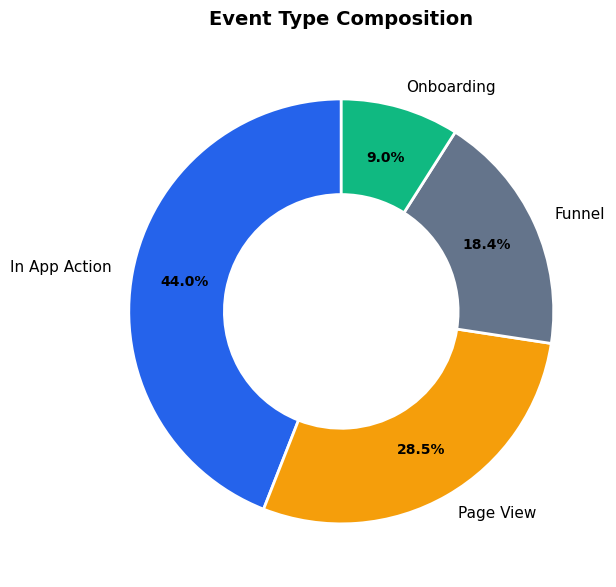

In [ ]:
# Event type distribution — donut chart
event_type_counts = clean_events['event_type'].value_counts()

fig, ax = plt.subplots(figsize=(8, 6))

colors = [COLORS['primary'], COLORS['accent'], COLORS['secondary'], COLORS['success']]
wedges, texts, autotexts = ax.pie(
    event_type_counts.values,
    labels=event_type_counts.index.str.replace('_', ' ').str.title(),
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2)
)

for t in autotexts:
    t.set_fontsize(10)
    t.set_fontweight('bold')

ax.set_title('Event Type Composition', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(r'C:\Users\alazp\Desktop\SaaS_Funnel_Analysis\charts\01_event_type_composition.png',
            bbox_inches='tight', dpi=150)
plt.show()

### 5.2 User Attribute Distributions

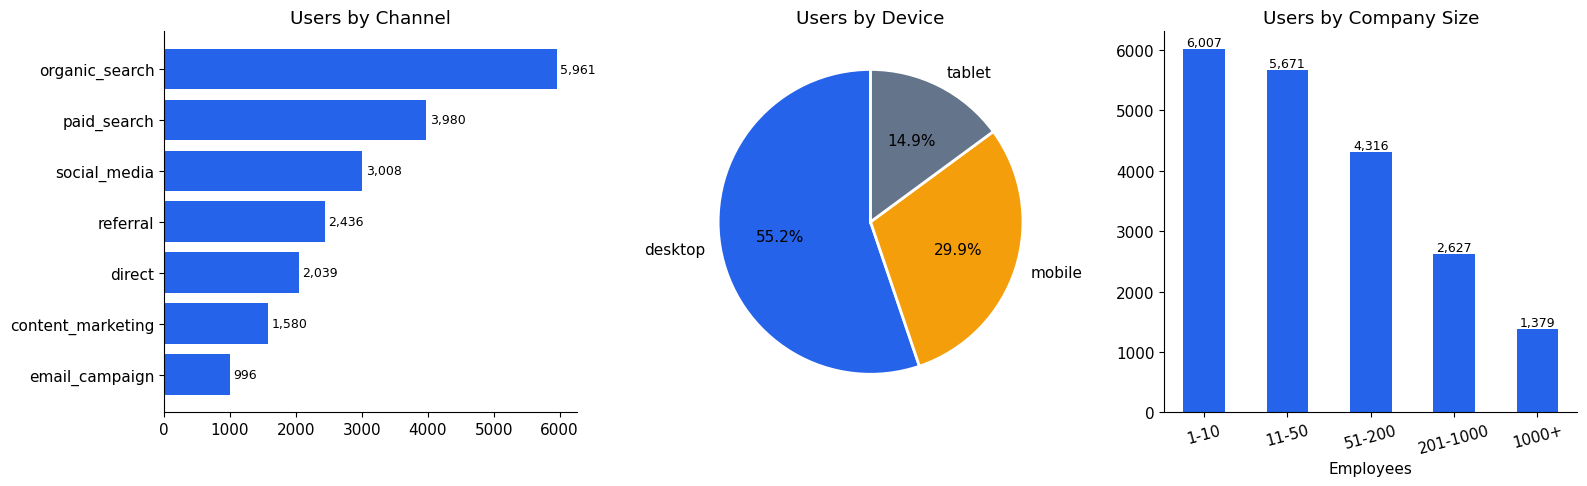

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
users = pd.read_csv(r'C:\Users\alazp\Desktop\SaaS_Funnel_Analysis\flowboard_users.csv')

# Channel — horizontal bar (keep as-is, works well for long labels)
ch = users['channel'].value_counts()
axes[0].barh(ch.index[::-1], ch.values[::-1], color=COLORS['primary'])
for i, v in enumerate(ch.values[::-1]):
    axes[0].text(v + 50, i, f'{v:,}', va='center', fontsize=9)
axes[0].set_title('Users by Channel')

# Device — pie chart (only 3 categories, proportions matter)
dev = users['device'].value_counts()
axes[1].pie(dev.values, labels=dev.index, autopct='%1.1f%%',
            colors=[COLORS['primary'], COLORS['accent'], COLORS['secondary']],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Users by Device')

# Company size — vertical bar (natural left-to-right ordering)
size_order = ['1-10', '11-50', '51-200', '201-1000', '1000+']
sz = users['company_size'].value_counts().reindex(size_order)
axes[2].bar(sz.index, sz.values, color=COLORS['primary'], width=0.5)
for j, v in enumerate(sz.values):
    axes[2].text(j, v + 50, f'{v:,}', ha='center', fontsize=9)
axes[2].set_title('Users by Company Size')
axes[2].set_xlabel('Employees')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(r'C:\Users\alazp\Desktop\SaaS_Funnel_Analysis\charts\01_user_distributions.png',
            bbox_inches='tight', dpi=150)
plt.show()

### 5.3 Monthly New Visitors

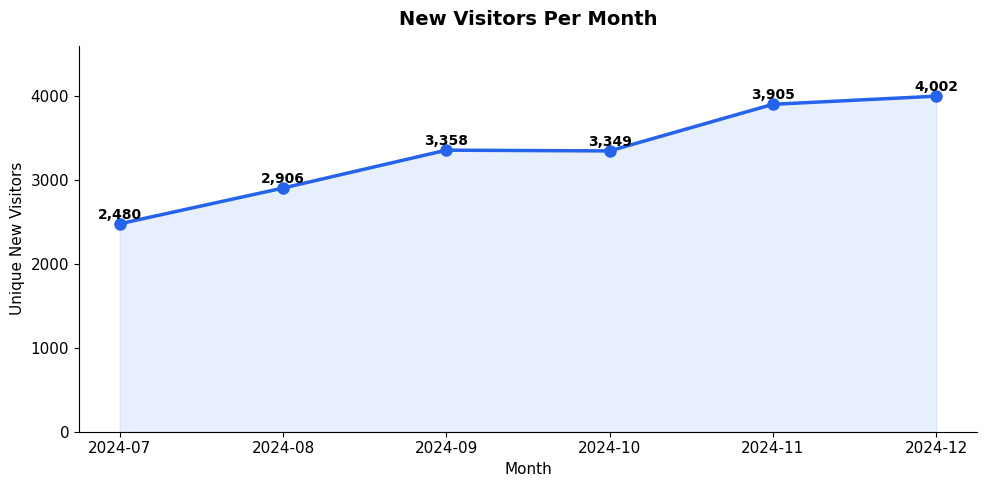

In [ ]:
# Monthly new visitors
monthly_visitors = clean_events[clean_events['event_name'] == 'visit_landing_page'].copy()
monthly_visitors['month'] = monthly_visitors['event_timestamp'].dt.to_period('M')
monthly_counts = monthly_visitors.groupby('month')['user_id'].nunique()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_counts.index.astype(str), monthly_counts.values,
        color=COLORS['primary'], marker='o', linewidth=2.5, markersize=8)

ax.fill_between(range(len(monthly_counts)), monthly_counts.values,
                alpha=0.1, color=COLORS['primary'])

for i, val in enumerate(monthly_counts.values):
    ax.text(i, val + 60, f'{val:,}', ha='center', fontsize=10, fontweight='bold')

ax.set_title('New Visitors Per Month', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Unique New Visitors')
ax.set_ylim(0, monthly_counts.max() * 1.15)

plt.tight_layout()
plt.savefig(r'C:\Users\alazp\Desktop\SaaS_Funnel_Analysis\charts\01_new_visitors_per_month.png',
            bbox_inches='tight', dpi=150)
plt.show()

### 5.4 User Engagement by Funnel Stage

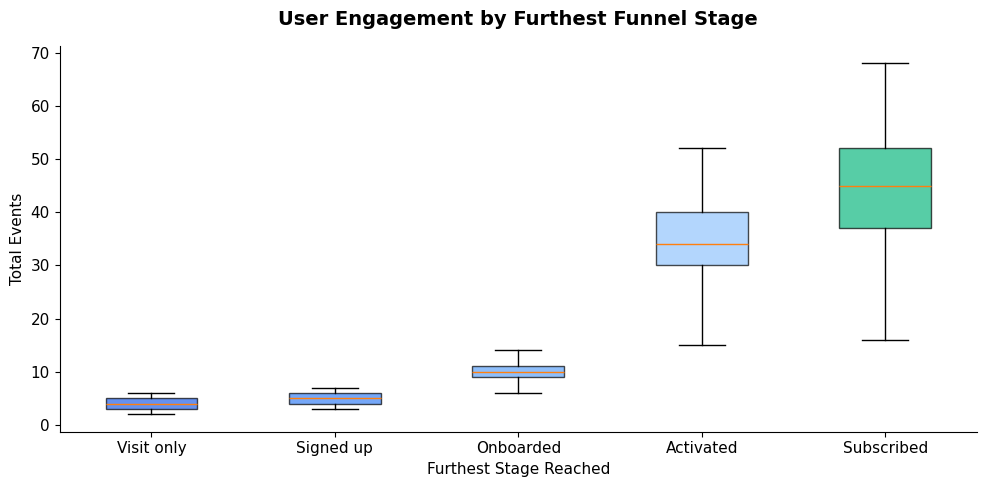

In [ ]:
# Events per user by furthest funnel stage
user_events = clean_events.groupby('user_id').size().reset_index(name='total_events')

user_stage = clean_events[clean_events['event_type'] == 'funnel'].copy()
stage_map = {'visit_landing_page': 1, 'sign_up': 2, 'complete_onboarding': 3,
             'activate_feature': 4, 'subscribe_paid': 5}
label_map = {1: 'Visit only', 2: 'Signed up', 3: 'Onboarded', 4: 'Activated', 5: 'Subscribed'}

user_stage['stage_num'] = user_stage['event_name'].map(stage_map)
user_max = user_stage.groupby('user_id')['stage_num'].max().reset_index()
user_max['stage_label'] = user_max['stage_num'].map(label_map)

merged = user_events.merge(user_max, on='user_id')

fig, ax = plt.subplots(figsize=(10, 5))

stage_order = ['Visit only', 'Signed up', 'Onboarded', 'Activated', 'Subscribed']
data_to_plot = [merged[merged['stage_label'] == s]['total_events'].values for s in stage_order]

bp = ax.boxplot(data_to_plot, labels=stage_order, patch_artist=True, showfliers=False)

for patch, color in zip(bp['boxes'], ['#2563EB', '#3B82F6', '#60A5FA', '#93C5FD', '#10B981']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('User Engagement by Furthest Funnel Stage', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Total Events')
ax.set_xlabel('Furthest Stage Reached')

plt.tight_layout()
plt.savefig(r'C:\Users\alazp\Desktop\SaaS_Funnel_Analysis\charts\01_engagement_by_stage.png',
            bbox_inches='tight', dpi=150)
plt.show()

---
## 6. Funnel Analysis

### 6.1 Overall Funnel

In [ ]:
funnel_df = pd.read_sql("""
    SELECT event_name AS funnel_stage, COUNT(DISTINCT user_id) AS unique_users
    FROM events_clean WHERE event_type = 'funnel'
    GROUP BY event_name
    ORDER BY CASE event_name
        WHEN 'visit_landing_page' THEN 1 WHEN 'sign_up' THEN 2
        WHEN 'complete_onboarding' THEN 3 WHEN 'activate_feature' THEN 4
        WHEN 'subscribe_paid' THEN 5 END
""", conn)

funnel_df['pct_of_total'] = (funnel_df['unique_users'] / funnel_df['unique_users'].iloc[0] * 100).round(1)
funnel_df

,funnel_stage,unique_users,pct_of_total
0,visit_landing_page,20000,100.00
1,sign_up,7651,38.30
2,complete_onboarding,5386,26.90
3,activate_feature,3256,16.30
4,subscribe_paid,1066,5.30


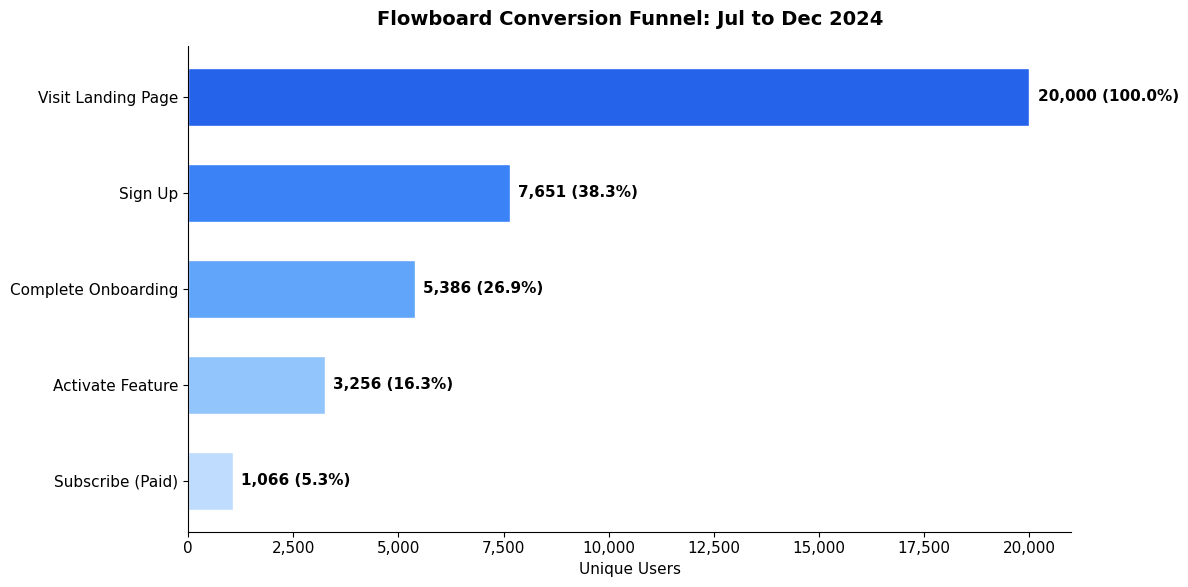

In [ ]:
funnel_df = pd.read_sql("""
    SELECT event_name AS funnel_stage, COUNT(DISTINCT user_id) AS unique_users
    FROM events_clean WHERE event_type = 'funnel'
    GROUP BY event_name
    ORDER BY CASE event_name
        WHEN 'visit_landing_page' THEN 1 WHEN 'sign_up' THEN 2
        WHEN 'complete_onboarding' THEN 3 WHEN 'activate_feature' THEN 4
        WHEN 'subscribe_paid' THEN 5 END
""", conn)

funnel_df['pct_of_total'] = (funnel_df['unique_users'] / funnel_df['unique_users'].iloc[0] * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 6))

y_positions = range(len(funnel_df))
bars = ax.barh(y_positions, funnel_df['unique_users'], color=FUNNEL_COLORS, height=0.6, edgecolor='white', linewidth=1)

ax.set_yticks(list(y_positions))
ax.set_yticklabels(FUNNEL_LABELS)
ax.invert_yaxis()

for bar, users, pct in zip(bars, funnel_df['unique_users'], funnel_df['pct_of_total']):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
            f'{users:,} ({pct}%)', va='center', fontsize=11, fontweight='bold')

ax.set_title('Flowboard Conversion Funnel: Jul to Dec 2024', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Unique Users')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig(r'C:\Users\alazp\Desktop\SaaS_Funnel_Analysis\charts\01_overall_funnel.png',
            bbox_inches='tight', dpi=150)
plt.show()

### 6.2 Stage-to-Stage Conversion Rates

In [ ]:
conversion_df = pd.read_sql("""
    WITH fc AS (
        SELECT event_name, COUNT(DISTINCT user_id) AS unique_users,
            CASE event_name WHEN 'visit_landing_page' THEN 1 WHEN 'sign_up' THEN 2
                WHEN 'complete_onboarding' THEN 3 WHEN 'activate_feature' THEN 4
                WHEN 'subscribe_paid' THEN 5 END AS stage_order
        FROM events_clean WHERE event_type = 'funnel' GROUP BY event_name
    )
    SELECT curr.event_name AS stage, curr.unique_users,
        prev.unique_users AS prev_stage_users,
        ROUND(100.0 * curr.unique_users / prev.unique_users, 1) AS conv_pct,
        ROUND(100.0 * (prev.unique_users - curr.unique_users) / prev.unique_users, 1) AS drop_off_pct
    FROM fc curr LEFT JOIN fc prev ON curr.stage_order = prev.stage_order + 1
    ORDER BY curr.stage_order
""", conn)

conversion_df


,stage,unique_users,prev_stage_users,conv_pct,drop_off_pct
0,visit_landing_page,20000,NaN,NaN,NaN
1,sign_up,7651,20000.00,38.30,61.70
2,complete_onboarding,5386,7651.00,70.40,29.60
3,activate_feature,3256,5386.00,60.50,39.50
4,subscribe_paid,1066,3256.00,32.70,67.30


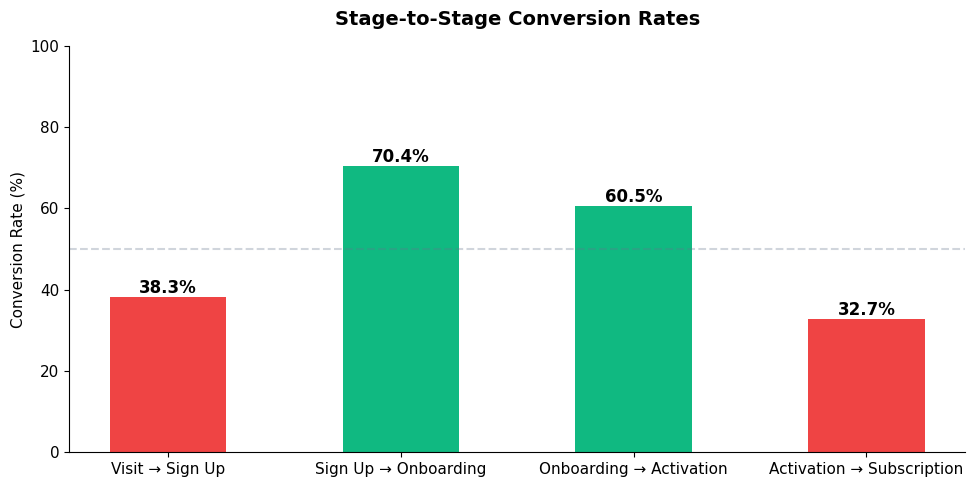

In [ ]:
conv_data = conversion_df.dropna(subset=['conv_pct'])
transitions = ['Visit → Sign Up', 'Sign Up → Onboarding', 'Onboarding → Activation', 'Activation → Subscription']

fig, ax = plt.subplots(figsize=(10, 5))

bar_colors = [COLORS['success'] if v >= 50 else COLORS['danger'] for v in conv_data['conv_pct']]
bars = ax.bar(transitions, conv_data['conv_pct'].values, color=bar_colors, width=0.5)

for bar, val in zip(bars, conv_data['conv_pct'].values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{val}%', ha='center', fontsize=12, fontweight='bold')

ax.set_ylim(0, 100)
ax.set_ylabel('Conversion Rate (%)')
ax.set_title('Stage-to-Stage Conversion Rates', fontsize=14, fontweight='bold', pad=15)
ax.axhline(y=50, color=COLORS['secondary'], linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(r'C:\Users\alazp\Desktop\SaaS_Funnel_Analysis\charts\01_stage_conversion.png', bbox_inches='tight', dpi=150)
plt.show()

### 6.3 Drop-Off Analysis

In [ ]:
dropoff_df = pd.read_sql("""
    WITH user_max_stage AS (
        SELECT user_id,
            MAX(CASE event_name
                WHEN 'visit_landing_page' THEN 1 WHEN 'sign_up' THEN 2
                WHEN 'complete_onboarding' THEN 3 WHEN 'activate_feature' THEN 4
                WHEN 'subscribe_paid' THEN 5 END
            ) AS max_stage
        FROM events_clean WHERE event_type = 'funnel' GROUP BY user_id
    )
    SELECT
        CASE max_stage
            WHEN 1 THEN 'Dropped after visit'
            WHEN 2 THEN 'Dropped after sign-up'
            WHEN 3 THEN 'Dropped after onboarding'
            WHEN 4 THEN 'Dropped after activation'
            WHEN 5 THEN 'Converted (subscribed)'
        END AS drop_off_point,
        COUNT(*) AS user_count,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct_of_users
    FROM user_max_stage GROUP BY max_stage ORDER BY max_stage
""", conn)

dropoff_df


,drop_off_point,user_count,pct_of_users
0,Dropped after visit,12348,61.70
1,Dropped after sign-up,2266,11.30
2,Dropped after onboarding,2130,10.70
3,Dropped after activation,2190,10.90
4,Converted (subscribed),1066,5.30


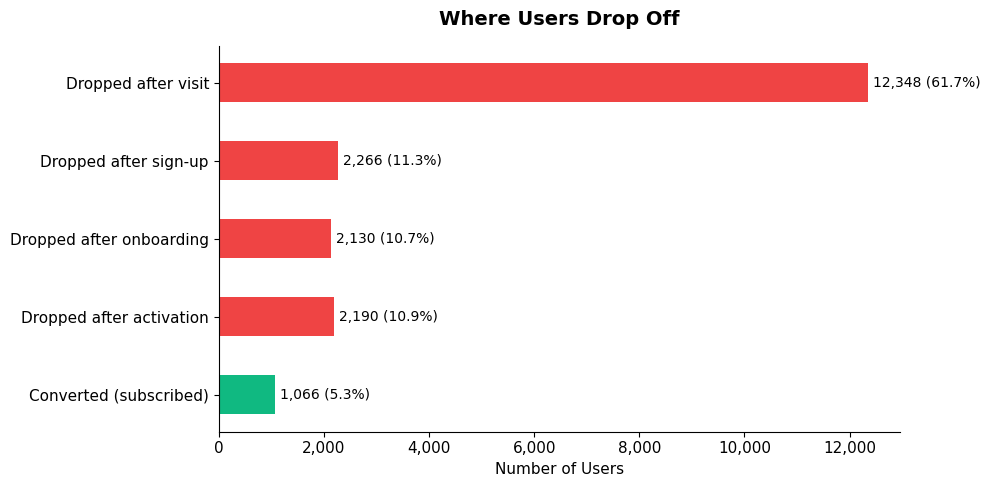

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = [COLORS['danger']] * 4 + [COLORS['success']]
bars = ax.barh(dropoff_df['drop_off_point'][::-1], dropoff_df['user_count'][::-1],
               color=colors[::-1], height=0.5)

for bar, pct in zip(bars, dropoff_df['pct_of_users'][::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():,.0f} ({pct}%)', va='center', fontsize=10)

ax.set_title('Where Users Drop Off', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Users')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig(r'C:\Users\alazp\Desktop\SaaS_Funnel_Analysis\charts\01_dropoff.png', bbox_inches='tight', dpi=150)
plt.show()

### 6.4 Time Between Funnel Stages

In [ ]:
time_summary = pd.read_sql("""
    WITH user_funnel AS (
        SELECT user_id, event_name, MIN(event_timestamp) AS first_time,
            CASE event_name WHEN 'visit_landing_page' THEN 1 WHEN 'sign_up' THEN 2
                WHEN 'complete_onboarding' THEN 3 WHEN 'activate_feature' THEN 4
                WHEN 'subscribe_paid' THEN 5 END AS stage_order
        FROM events_clean WHERE event_type = 'funnel'
        GROUP BY user_id, event_name
    ),
    time_between AS (
        SELECT prev.event_name || ' → ' || curr.event_name AS transition,
            ROUND((JULIANDAY(curr.first_time) - JULIANDAY(prev.first_time)) * 24, 2) AS hours,
            prev.stage_order AS from_order
        FROM user_funnel curr
        INNER JOIN user_funnel prev
            ON curr.user_id = prev.user_id AND curr.stage_order = prev.stage_order + 1
    )
    SELECT transition, COUNT(*) AS users,
        ROUND(AVG(hours), 1) AS avg_hours,
        ROUND(MIN(hours), 1) AS min_hours,
        ROUND(MAX(hours), 1) AS max_hours
    FROM time_between
    GROUP BY transition, from_order ORDER BY from_order
""", conn)

time_summary

,transition,users,avg_hours,min_hours,max_hours
0,visit_landing_page → sign_up,7651,0.40,0.00,0.80
1,sign_up → complete_onboarding,5385,22.10,0.10,72.10
2,complete_onboarding → activate_feature,3256,27.00,1.40,52.30
3,activate_feature → subscribe_paid,1066,178.10,24.10,335.70


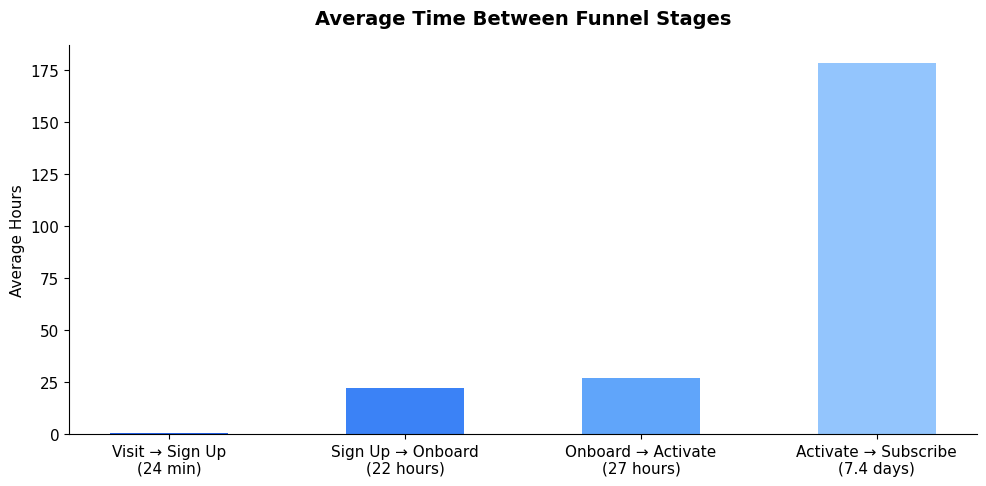

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

transitions = ['Visit → Sign Up', 'Sign Up → Onboard', 'Onboard → Activate', 'Activate → Subscribe']
medians = [time_summary['avg_hours'].iloc[0], time_summary['avg_hours'].iloc[1],
           time_summary['avg_hours'].iloc[2], time_summary['avg_hours'].iloc[3]]

# Convert to more readable units
labels_with_time = []
for t, m in zip(transitions, medians):
    if m < 1:
        labels_with_time.append(f'{t}\n({m*60:.0f} min)')
    elif m < 48:
        labels_with_time.append(f'{t}\n({m:.0f} hours)')
    else:
        labels_with_time.append(f'{t}\n({m/24:.1f} days)')

bars = ax.bar(labels_with_time, medians, color=FUNNEL_COLORS[:4], width=0.5)

ax.set_ylabel('Average Hours')
ax.set_title('Average Time Between Funnel Stages', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(r'C:\Users\alazp\Desktop\SaaS_Funnel_Analysis\charts\01_time_between_stages.png',
            bbox_inches='tight', dpi=150)
plt.show()

### 6.5 Monthly Funnel Trends

In [ ]:
monthly_df = pd.read_sql("""
    WITH mf AS (
        SELECT STRFTIME('%Y-%m', event_timestamp) AS month, event_name,
            COUNT(DISTINCT user_id) AS unique_users
        FROM events_clean WHERE event_type = 'funnel'
        GROUP BY month, event_name
    )
    SELECT month,
        MAX(CASE WHEN event_name = 'visit_landing_page' THEN unique_users END) AS visitors,
        MAX(CASE WHEN event_name = 'sign_up' THEN unique_users END) AS signups,
        MAX(CASE WHEN event_name = 'complete_onboarding' THEN unique_users END) AS onboarded,
        MAX(CASE WHEN event_name = 'activate_feature' THEN unique_users END) AS activated,
        MAX(CASE WHEN event_name = 'subscribe_paid' THEN unique_users END) AS subscribed,
        ROUND(100.0 * MAX(CASE WHEN event_name = 'subscribe_paid' THEN unique_users END) /
            NULLIF(MAX(CASE WHEN event_name = 'visit_landing_page' THEN unique_users END), 0), 1) AS overall_conv_pct
    FROM mf GROUP BY month ORDER BY month
""", conn)

monthly_df

,month,visitors,signups,onboarded,activated,subscribed,overall_conv_pct
0,2024-07,2480,808,501,247,51,2.10
1,2024-08,2906,1050,694,398,109,3.80
2,2024-09,3358,1412,1023,656,206,6.10
3,2024-10,3349,1112,659,344,133,4.00
4,2024-11,3905,1556,1159,689,214,5.50
5,2024-12,4002,1713,1350,922,353,8.80


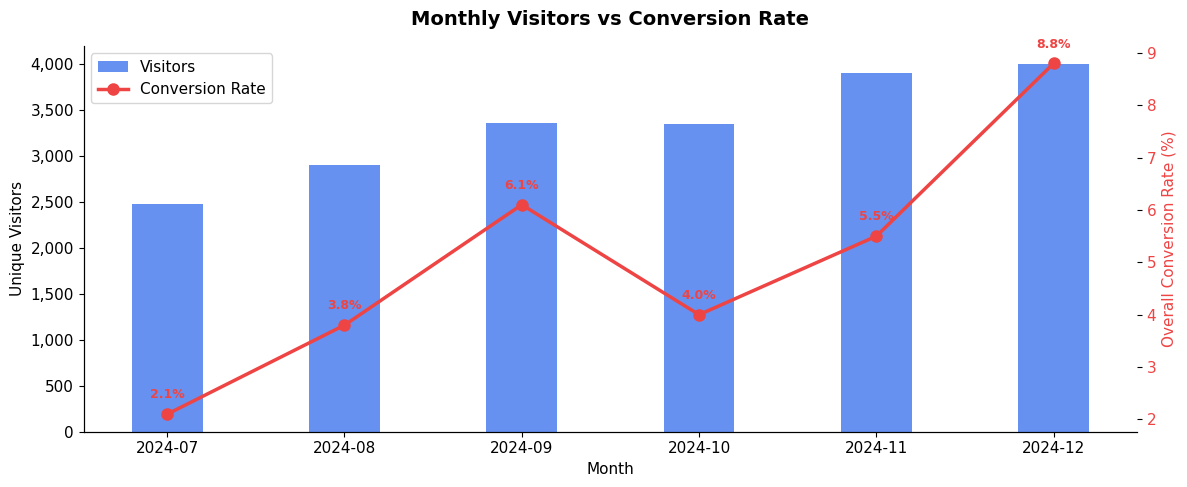

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# Bar chart (Visitors)
bars = ax1.bar(
    monthly_df['month'],
    monthly_df['visitors'],
    color=COLORS['primary'],
    width=0.4,
    alpha=0.7,
    label='Visitors'
)

ax1.set_ylabel('Unique Visitors')
ax1.set_xlabel('Month')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Line chart (Conversion Rate)
ax2 = ax1.twinx()
line = ax2.plot(
    monthly_df['month'],
    monthly_df['overall_conv_pct'],
    marker='o',
    color=COLORS['danger'],
    linewidth=2.5,
    markersize=8,
    label='Conversion Rate'
)

ax2.set_ylabel('Overall Conversion Rate (%)', color=COLORS['danger'])
ax2.tick_params(axis='y', labelcolor=COLORS['danger'])

# Annotate conversion values
for i, val in enumerate(monthly_df['overall_conv_pct']):
    if pd.notna(val):
        ax2.text(
            i,
            val + 0.3,
            f'{val}%',
            ha='center',
            fontsize=9,
            color=COLORS['danger'],
            fontweight='bold'
        )

# --- Combined legend ---
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='upper left'
)

# Title (fixed)
ax1.set_title(
    'Monthly Visitors vs Conversion Rate',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.tight_layout()

plt.savefig(
    r'C:\Users\alazp\Desktop\SaaS_Funnel_Analysis\charts\01_monthly_funnel.png',
    bbox_inches='tight',
    dpi=150
)

plt.show()

### 6.6 Sessions Before Conversion

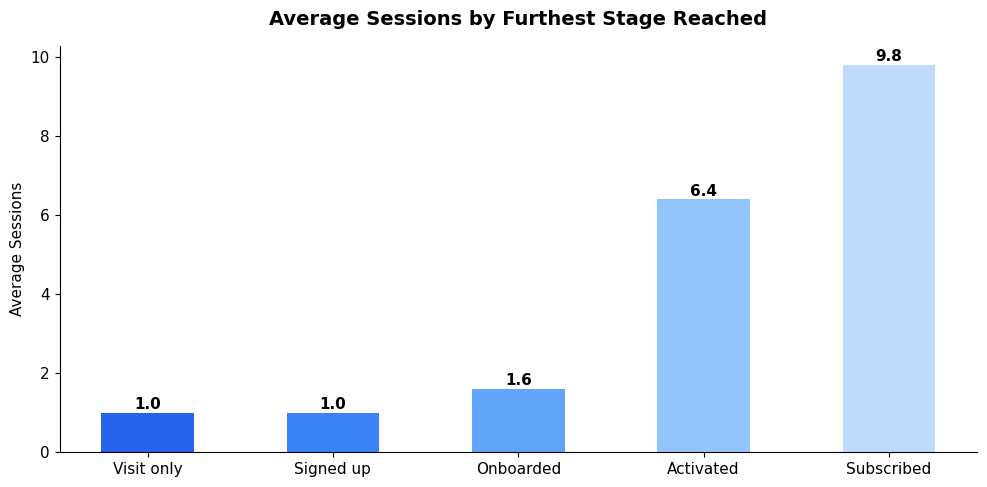

In [ ]:
session_df = pd.read_sql("""
    WITH us AS (
        SELECT user_id, COUNT(DISTINCT session_id) AS total_sessions
        FROM events_clean GROUP BY user_id
    ),
    ums AS (
        SELECT user_id,
            MAX(CASE event_name WHEN 'visit_landing_page' THEN 1 WHEN 'sign_up' THEN 2
                WHEN 'complete_onboarding' THEN 3 WHEN 'activate_feature' THEN 4
                WHEN 'subscribe_paid' THEN 5 END) AS max_stage
        FROM events_clean WHERE event_type = 'funnel' GROUP BY user_id
    )
    SELECT CASE ums.max_stage WHEN 1 THEN 'Visit only' WHEN 2 THEN 'Signed up'
            WHEN 3 THEN 'Onboarded' WHEN 4 THEN 'Activated' WHEN 5 THEN 'Subscribed' END AS stage,
        COUNT(*) AS users, ROUND(AVG(us.total_sessions), 1) AS avg_sessions
    FROM ums JOIN us ON ums.user_id = us.user_id
    GROUP BY ums.max_stage ORDER BY ums.max_stage
""", conn)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(session_df['stage'], session_df['avg_sessions'], color=FUNNEL_COLORS, width=0.5)
for bar, val in zip(bars, session_df['avg_sessions']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f'{val}', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Average Sessions by Furthest Stage Reached', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Average Sessions')

plt.tight_layout()
plt.savefig(r'C:\Users\alazp\Desktop\SaaS_Funnel_Analysis\charts\01_sessions_by_stage.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 7. Segmentation Analysis

### 7.1 Funnel by Acquisition Channel

In [ ]:
channel_df = pd.read_sql("""
    WITH cf AS (
        SELECT channel,
            COUNT(DISTINCT CASE WHEN event_name = 'visit_landing_page' THEN user_id END) AS visitors,
            COUNT(DISTINCT CASE WHEN event_name = 'sign_up' THEN user_id END) AS signups,
            COUNT(DISTINCT CASE WHEN event_name = 'complete_onboarding' THEN user_id END) AS onboarded,
            COUNT(DISTINCT CASE WHEN event_name = 'activate_feature' THEN user_id END) AS activated,
            COUNT(DISTINCT CASE WHEN event_name = 'subscribe_paid' THEN user_id END) AS subscribed
        FROM events_clean WHERE event_type = 'funnel' GROUP BY channel
    )
    SELECT channel, visitors, signups, onboarded, activated, subscribed,
        ROUND(100.0 * signups / NULLIF(visitors, 0), 1) AS visit_to_signup,
        ROUND(100.0 * onboarded / NULLIF(signups, 0), 1) AS signup_to_onboard,
        ROUND(100.0 * activated / NULLIF(onboarded, 0), 1) AS onboard_to_activate,
        ROUND(100.0 * subscribed / NULLIF(activated, 0), 1) AS activate_to_subscribe,
        ROUND(100.0 * subscribed / NULLIF(visitors, 0), 1) AS overall_conv
    FROM cf ORDER BY overall_conv DESC
""", conn)

channel_df

,channel,visitors,signups,onboarded,activated,subscribed,visit_to_signup,signup_to_onboard,onboard_to_activate,activate_to_subscribe,overall_conv
0,referral,2436,1263,1077,787,305,51.80,85.30,73.10,38.80,12.50
1,direct,2039,859,657,410,150,42.10,76.50,62.40,36.60,7.40
2,content_marketing,1580,712,567,364,114,45.10,79.60,64.20,31.30,7.20
3,organic_search,5961,2436,1776,1103,344,40.90,72.90,62.10,31.20,5.80
4,email_campaign,996,350,224,117,40,35.10,64.00,52.20,34.20,4.00
5,paid_search,3980,1265,706,333,87,31.80,55.80,47.20,26.10,2.20
6,social_media,3008,766,379,142,26,25.50,49.50,37.50,18.30,0.90


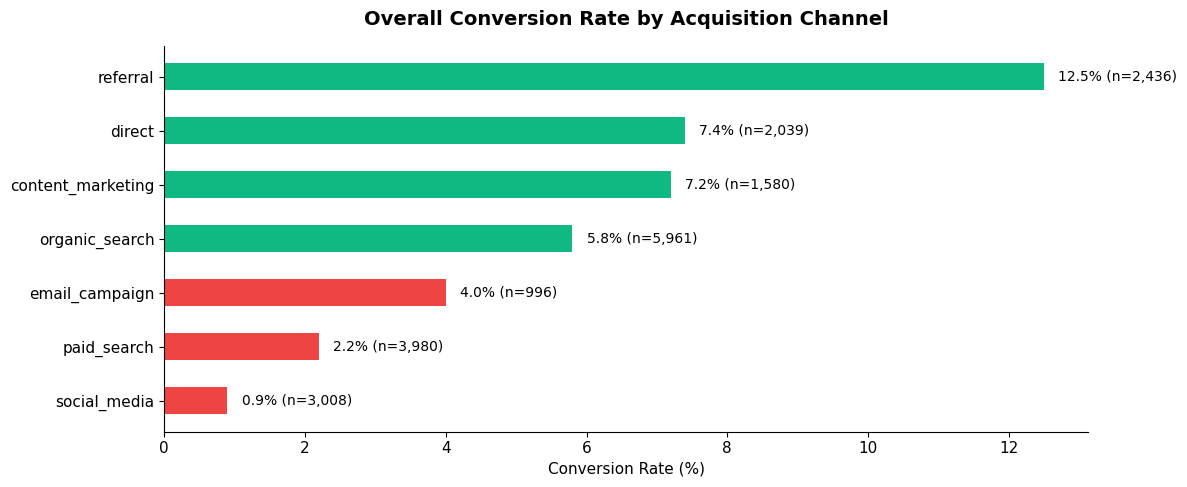

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

ch_sorted = channel_df.sort_values('overall_conv', ascending=True)
colors = [COLORS['success'] if v >= channel_df['overall_conv'].median() else COLORS['danger']
          for v in ch_sorted['overall_conv']]

bars = ax.barh(ch_sorted['channel'], ch_sorted['overall_conv'], color=colors, height=0.5)
for bar, visitors in zip(bars, ch_sorted['visitors']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.1f}% (n={visitors:,})', va='center', fontsize=10)

ax.set_title('Overall Conversion Rate by Acquisition Channel', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Conversion Rate (%)')

plt.tight_layout()
plt.savefig(r'C:\Users\alazp\Desktop\SaaS_Funnel_Analysis\charts\01_channel_conversion.png', bbox_inches='tight', dpi=150)
plt.show()

### 7.2 Funnel by Device Type

In [ ]:
device_df = pd.read_sql("""
    WITH df AS (
        SELECT device,
            COUNT(DISTINCT CASE WHEN event_name = 'visit_landing_page' THEN user_id END) AS visitors,
            COUNT(DISTINCT CASE WHEN event_name = 'sign_up' THEN user_id END) AS signups,
            COUNT(DISTINCT CASE WHEN event_name = 'complete_onboarding' THEN user_id END) AS onboarded,
            COUNT(DISTINCT CASE WHEN event_name = 'activate_feature' THEN user_id END) AS activated,
            COUNT(DISTINCT CASE WHEN event_name = 'subscribe_paid' THEN user_id END) AS subscribed
        FROM events_clean WHERE event_type = 'funnel' GROUP BY device
    )
    SELECT device, visitors, subscribed,
        ROUND(100.0 * signups / NULLIF(visitors, 0), 1) AS visit_to_signup,
        ROUND(100.0 * onboarded / NULLIF(signups, 0), 1) AS signup_to_onboard,
        ROUND(100.0 * activated / NULLIF(onboarded, 0), 1) AS onboard_to_activate,
        ROUND(100.0 * subscribed / NULLIF(activated, 0), 1) AS activate_to_subscribe,
        ROUND(100.0 * subscribed / NULLIF(visitors, 0), 1) AS overall_conv
    FROM df ORDER BY overall_conv DESC
""", conn)

device_df

,device,visitors,subscribed,visit_to_signup,signup_to_onboard,onboard_to_activate,activate_to_subscribe,overall_conv
0,desktop,11039,883,44.70,77.90,65.90,34.90,8.00
1,tablet,2981,86,32.60,61.10,50.90,28.50,2.90
2,mobile,5980,97,29.20,54.40,44.50,22.90,1.60


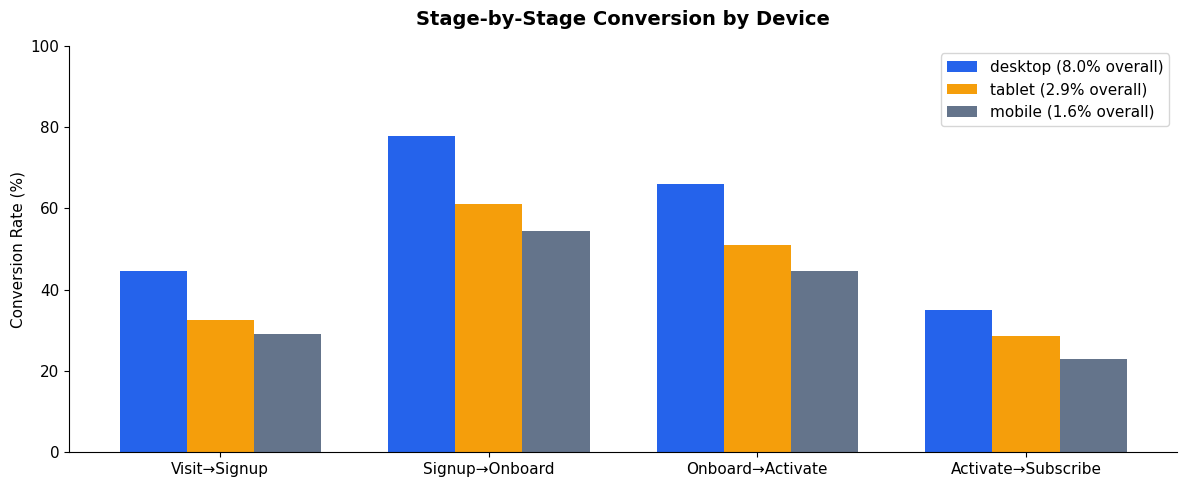

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

stages = ['visit_to_signup', 'signup_to_onboard', 'onboard_to_activate', 'activate_to_subscribe']
stage_labels = ['Visit→Signup', 'Signup→Onboard', 'Onboard→Activate', 'Activate→Subscribe']
device_colors = [COLORS['primary'], COLORS['accent'], COLORS['secondary']]

x = np.arange(len(stages))
width = 0.25

for i, (_, row) in enumerate(device_df.iterrows()):
    vals = [row[s] for s in stages]
    ax.bar(x + i * width - width, vals, width,
           label=f'{row["device"]} ({row["overall_conv"]:.1f}% overall)', color=device_colors[i])

ax.set_xticks(x)
ax.set_xticklabels(stage_labels)
ax.set_ylabel('Conversion Rate (%)')
ax.set_title('Stage-by-Stage Conversion by Device', fontsize=14, fontweight='bold', pad=15)
ax.legend()
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig(r'C:\Users\alazp\Desktop\SaaS_Funnel_Analysis\charts\01_device_conversion.png', bbox_inches='tight', dpi=150)
plt.show()

### 7.3 Funnel by Company Size

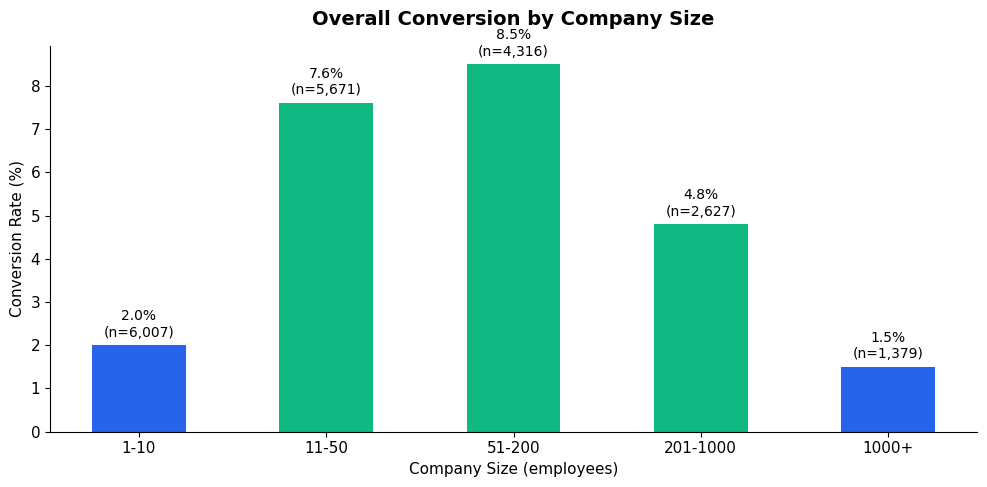

In [ ]:
size_df = pd.read_sql("""
    WITH sf AS (
        SELECT company_size,
            COUNT(DISTINCT CASE WHEN event_name = 'visit_landing_page' THEN user_id END) AS visitors,
            COUNT(DISTINCT CASE WHEN event_name = 'subscribe_paid' THEN user_id END) AS subscribed
        FROM events_clean WHERE event_type = 'funnel' GROUP BY company_size
    )
    SELECT company_size, visitors, subscribed,
        ROUND(100.0 * subscribed / NULLIF(visitors, 0), 1) AS overall_conv
    FROM sf
    ORDER BY CASE company_size
        WHEN '1-10' THEN 1 WHEN '11-50' THEN 2 WHEN '51-200' THEN 3
        WHEN '201-1000' THEN 4 WHEN '1000+' THEN 5 END
""", conn)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [COLORS['success'] if v >= size_df['overall_conv'].median() else COLORS['primary']
          for v in size_df['overall_conv']]
bars = ax.bar(size_df['company_size'], size_df['overall_conv'], color=colors, width=0.5)

for bar, val, visitors in zip(bars, size_df['overall_conv'], size_df['visitors']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f'{val}%\n(n={visitors:,})', ha='center', fontsize=10)

ax.set_title('Overall Conversion by Company Size', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Company Size (employees)')
ax.set_ylabel('Conversion Rate (%)')

plt.tight_layout()
plt.savefig(r'C:\Users\alazp\Desktop\SaaS_Funnel_Analysis\charts\01_company_size_conversion.png', bbox_inches='tight', dpi=150)
plt.show()

### 7.4 Onboarding Depth vs Conversion

In [ ]:
onboarding_df = pd.read_sql("""
    WITH os AS (
        SELECT user_id, COUNT(*) AS steps
        FROM events_clean WHERE event_type = 'onboarding' GROUP BY user_id
    ),
    ua AS (SELECT DISTINCT user_id FROM events_clean WHERE event_name = 'activate_feature'),
    us AS (SELECT DISTINCT user_id FROM events_clean WHERE event_name = 'subscribe_paid')
    SELECT os.steps AS steps_completed, COUNT(*) AS users,
        SUM(CASE WHEN ua.user_id IS NOT NULL THEN 1 ELSE 0 END) AS activated,
        ROUND(100.0 * SUM(CASE WHEN ua.user_id IS NOT NULL THEN 1 ELSE 0 END) / COUNT(*), 1) AS activation_rate,
        SUM(CASE WHEN us.user_id IS NOT NULL THEN 1 ELSE 0 END) AS subscribed,
        ROUND(100.0 * SUM(CASE WHEN us.user_id IS NOT NULL THEN 1 ELSE 0 END) / COUNT(*), 1) AS sub_rate
    FROM os LEFT JOIN ua ON os.user_id = ua.user_id LEFT JOIN us ON os.user_id = us.user_id
    GROUP BY os.steps ORDER BY os.steps
""", conn)

onboarding_df

,steps_completed,users,activated,activation_rate,subscribed,sub_rate
0,2,1092,651,59.60,218,20.00
1,3,1063,636,59.80,210,19.80
2,4,3231,1969,60.90,638,19.70


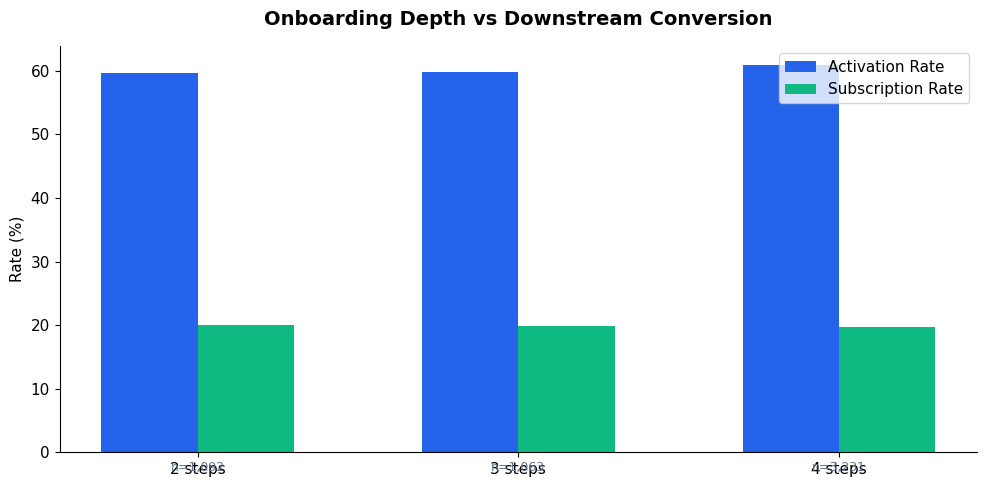

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(onboarding_df))
width = 0.3

ax.bar(x - width/2, onboarding_df['activation_rate'], width,
       label='Activation Rate', color=COLORS['primary'])
ax.bar(x + width/2, onboarding_df['sub_rate'], width,
       label='Subscription Rate', color=COLORS['success'])

ax.set_xticks(x)
ax.set_xticklabels([f'{s} steps' for s in onboarding_df['steps_completed']])
ax.set_ylabel('Rate (%)')
ax.set_title('Onboarding Depth vs Downstream Conversion', fontsize=14, fontweight='bold', pad=15)
ax.legend()

for i, users in enumerate(onboarding_df['users']):
    ax.text(i, -3, f'n={users:,}', ha='center', fontsize=9, color=COLORS['secondary'])

plt.tight_layout()
plt.savefig(r'C:\Users\alazp\Desktop\SaaS_Funnel_Analysis\charts\01_onboarding_depth.png', bbox_inches='tight', dpi=150)
plt.show()

### 7.5 Cross-Segment: Channel × Device

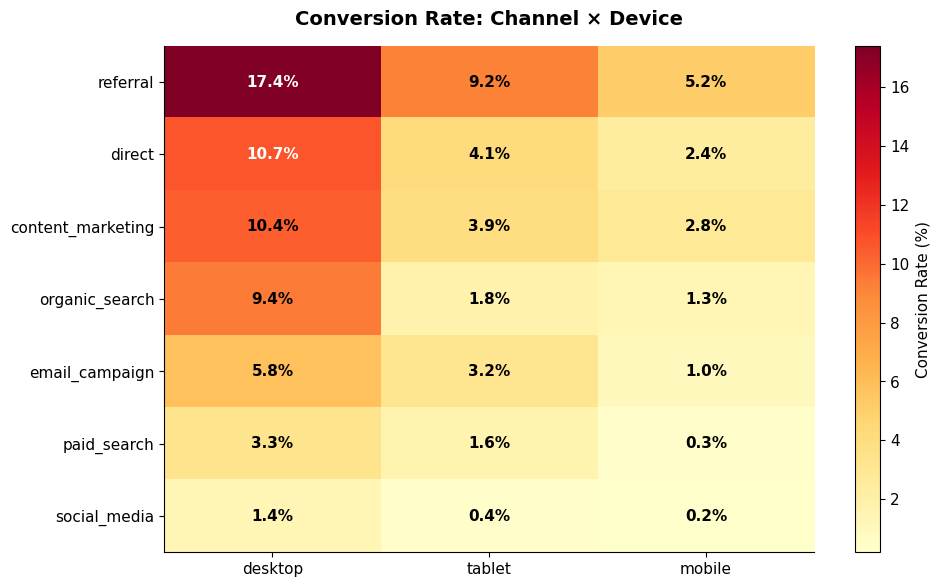

In [ ]:
cross_df = pd.read_sql("""
    SELECT channel, device,
        COUNT(DISTINCT CASE WHEN event_name = 'visit_landing_page' THEN user_id END) AS visitors,
        COUNT(DISTINCT CASE WHEN event_name = 'subscribe_paid' THEN user_id END) AS subscribed,
        ROUND(100.0 *
            COUNT(DISTINCT CASE WHEN event_name = 'subscribe_paid' THEN user_id END) /
            NULLIF(COUNT(DISTINCT CASE WHEN event_name = 'visit_landing_page' THEN user_id END), 0),
        1) AS overall_conv
    FROM events_clean WHERE event_type = 'funnel'
    GROUP BY channel, device HAVING visitors >= 50
    ORDER BY overall_conv DESC
""", conn)

pivot = cross_df.pivot_table(index='channel', columns='device', values='overall_conv', fill_value=0)
channel_order = channel_df.sort_values('overall_conv', ascending=False)['channel'].tolist()
pivot = pivot.reindex(index=channel_order, columns=['desktop', 'tablet', 'mobile'], fill_value=0)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(3))
ax.set_xticklabels(['desktop', 'tablet', 'mobile'])
ax.set_yticks(range(len(channel_order)))
ax.set_yticklabels(channel_order)

for i in range(len(channel_order)):
    for j in range(3):
        val = pivot.values[i, j]
        color = 'white' if val > pivot.values.max() * 0.6 else 'black'
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center', color=color, fontsize=11, fontweight='bold')

ax.set_title('Conversion Rate: Channel × Device', fontsize=14, fontweight='bold', pad=15)
plt.colorbar(im, ax=ax, label='Conversion Rate (%)')

plt.tight_layout()
plt.savefig(r'C:\Users\alazp\Desktop\SaaS_Funnel_Analysis\charts\01_channel_device_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
conn.close()

---
## 8. Analysis Summary

### Funnel overview
- **Overall conversion:** ~5.3% (20,000 visitors → 1,066 subscribers)
- **Biggest volume loss:** Visit → Sign-up (61.7% drop-off, ~12,300 users lost)
- **Biggest rate drop:** Activation → Subscription (67.3% drop-off)
- October shows a noticeable conversion dip across all stages

### Segment highlights
- **Referral** converts at 12.5%: more than double any other channel
- **Desktop** converts at 8.0% vs mobile at 1.6%: a 5x gap
- **Mid-size companies** (11–200) are the self-serve sweet spot
- **Onboarding completion** strongly predicts downstream conversion
- Best combo: referral + desktop. Worst: social media + mobile.

See Notebook 2 for presentation-ready charts and business recommendations.